In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import textwrap
import wrds
import os

### Compustat

In [3]:
def get_large_cap_industry_groups(min_mktcap_mm=10000, username='your_username'):
    """
    Fetches large-cap firms, calculates Market Cap, groups by 4-digit NAICS, 
    and returns a cleaned dataframe for pair trade research.
    """
    db = wrds.Connection(wrds_username=username)

    # SQL Query Strategy:
    # 1. Join Fundamentals (funda) with Company Info (company)
    # 2. Filter for latest fiscal year records
    # 3. Calculate Market Cap (Price * Shares)
    # 4. Extract 4-digit Industry Group from NAICS
    sql_query = f"""
        SELECT 
            a.gvkey, a.tic, b.conm, a.fyear, a.datadate,
            a.csho, a.prcc_f, (a.csho * a.prcc_f) as mktcap,
            b.naics
        FROM 
            comp.funda a
        JOIN 
            comp.company b ON a.gvkey = b.gvkey
        WHERE 
            a.indfmt = 'INDL'     -- Industrial Format
            AND a.datafmt = 'STD' -- Standardized
            AND a.popsrc = 'D'    -- Domestic
            AND a.consol = 'C'    -- Consolidated
            AND a.fyear = 2024    -- Use latest complete fiscal year
            AND (a.csho * a.prcc_f) >= {min_mktcap_mm}
    """
    
    print(f"Querying WRDS for firms with Mkt Cap > ${min_mktcap_mm}MM...")
    df = db.raw_sql(sql_query)
    db.close()

    # 1. Clean NAICS and create 'Industry_Group' (First 4 digits)
    df = df.dropna(subset=['naics'])
    df['naics'] = df['naics'].astype(str)
    df['industry_group'] = df['naics'].str[:4]
    df['NAICS_Industry'] = df['naics'].str[:5]

    # 2. Add Industry Descriptions (Optional but helpful for research)
    # You could merge with a NAICS mapping file here. 

    # 3. Sort by Industry Group and Market Cap
    df = df.sort_values(['industry_group', 'mktcap'], ascending=[True, False])

    # 4. Final selection of columns for Pair Trade Research
    final_df = df[[
        'gvkey', 'tic', 'conm', 'industry_group', 'mktcap', 'naics', 'NAICS_Industry'
    ]]

    # Save to CSV
    filename = "large_cap_pairs_universe.csv"
    final_df.to_csv(filename, index=False)
    print(f"File saved: {filename}")
    
    return final_df

# Define Large Cap as > $10 Billion
group_df = pd.read_csv("large_cap_pairs_universe.csv", header=0) if os.path.exists("large_cap_pairs_universe.csv") else get_large_cap_industry_groups(min_mktcap_mm=10000)  # Replace 'username' with your actual WRDS username

In [4]:
DATA_DIR = Path("data_cache")
DATA_DIR.mkdir(exist_ok=True)

In [5]:
def fetch_log_prices(tickers: list, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Downloads Adjusted Close prices for multiple tickers, handles missing data,
    and computes their log-prices for pairs trading analysis.
    """
    try:
        # Download data silently
        # --- create filename ---
        file_name = f"{'_'.join(sorted(tickers))}_{start_date}_{end_date}.csv"
        file_path = DATA_DIR / file_name
        
        # --- load if exists ---
        if file_path.exists():
            data = pd.read_csv(file_path, index_col=0, parse_dates=True)
        
        # --- otherwise download and save ---
        else:
            data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']
            data.to_csv(file_path)
            
        data = np.log(data)  # Compute log-prices
        
        # Error handling for empty data or missing tickers
        if data.empty:
            raise ValueError("No data returned from yfinance. Check date ranges and network connection.")
        for ticker in tickers:
            if ticker not in data.columns:
                raise ValueError(f"Ticker {ticker} is invalid or has no data.")
            
        # Drop NaN values to ensure aligned time series for regression
        data = data.dropna()
        
        if len(data) < 30:
            raise ValueError("Insufficient data points after dropping NaNs (need at least 30 days of overlap).")

        return data
        
    except Exception as e:
        print(f"Error fetching data: {str(e)}")
        return pd.DataFrame()

### Prescreening

In [6]:
def calculate_npd(log_prices: pd.DataFrame, ticker1: str, ticker2: str) -> float:
    """
    Computes the Normalized Price Distance (NPD) using log-prices.
    Formula: Mean of squared differences of shifted log-prices (y_t - y_0)
    """
    y1 = log_prices[ticker1]
    y2 = log_prices[ticker2]
    
    # Normalize by subtracting the initial value (y_0) 
    y1_norm = y1 - y1.iloc[0]
    y2_norm = y2 - y2.iloc[0]
    
    # Calculate average squared distance
    npd = np.mean((y1_norm - y2_norm)**2)
    return npd

def test_cointegration(log_data: pd.DataFrame, ticker1: str, ticker2: str):
    """
    Performs OLS to find the hedge ratio and runs ADF on the spread to test for stationarity.
    Returns: (p-value, gamma, spread)
    """
    try:
        y1 = log_data[ticker1]
        y2 = log_data[ticker2]
        
        # OLS regression to determine gamma 
        X = sm.add_constant(y2)
        model = sm.OLS(y1, X).fit()
        gamma = model.params.iloc[1]
        
        # Construct the spread z_t = y1 - gamma * y2 [cite: 83]
        spread = y1 - gamma * y2
        
        # ADF Test for stationarity [cite: 91, 97]
        adf_result = adfuller(spread, autolag='AIC')
        p_value = adf_result[1]
        
        return p_value, gamma, spread
    except Exception:
        return 1.0, None, None

def discover_best_pair(tickers: list, start_date: str, end_date: str, top_k: int = 5):
    """
    Stage 1: Prescreening using NPD[cite: 73].
    Stage 2: Statistical testing using ADF on the Top-K candidates.
    """

    log_prices = fetch_log_prices(tickers, start_date, end_date)
    
    if log_prices.empty or len(log_prices.columns) < 2:
        print("Insufficient data for the provided tickers.")
        return None
    
    # --- STAGE 1: PRESCREENING (NPD) ---
    all_pairs = list(combinations(log_prices.columns, 2))
    screening_results = []
    
    for t1, t2 in all_pairs:
        npd_score = calculate_npd(log_prices, t1, t2)
        screening_results.append({'pair': (t1, t2), 'npd': npd_score})
    
    # Rank by lowest distance (heuristic for cointegration) [cite: 73, 74]
    screened_pairs = sorted(screening_results, key=lambda x: x['npd'])[:top_k]
    
    print(f"Prescreening complete. Testing top {top_k} candidates for cointegration...")
    
    # --- STAGE 2: COINTEGRATION TESTING (ADF) ---
    final_results = []
    for candidate in screened_pairs:
        t1, t2 = candidate['pair']
        p_val, gamma, spread = test_cointegration(log_prices, t1, t2)
        
        final_results.append({
            'tickers': (t1, t2),
            'npd': candidate['npd'],
            'p_value': p_val,
            'gamma': gamma
        })
        print(f"Tested {t1}-{t2}: NPD={candidate['npd']:.4f}, ADF p-value={p_val:.4f}")

    # Pick pairs with p-value < 0.05 as statistically significant [cite: 91, 97]
    best = min(final_results, key=lambda x: x['p_value']) if final_results else None
    '''
    print("\n" + "="*50)
    print("PAIR DISCOVERY SUMMARY")
    print("="*50)
    if best:
        best_pair = best
        print(f"BEST PAIR: {best_pair['tickers'][0]} & {best_pair['tickers'][1]}")
        print(f"ADF p-value: {best_pair['p_value']:.5f}")
        print(f"Hedge Ratio (Gamma): {best_pair['gamma']:.4f}")
        print(f"NPD (Prescreen): {best_pair['npd']:.6f}")
    else:
        print("No statistically significant cointegrated pairs found (p > 0.05).")
    print("="*50)
    '''
    return best

### Load daily and monthly Carhart-4-factor model

In [ ]:
factor_df = pd.read_csv('carhart/F-F_Research_Data_Factors_daily.csv', skiprows=4, header=0)
mom_df = pd.read_csv('carhart/F-F_Momentum_Factor_daily.csv', skiprows=13, header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m%d', errors='coerce')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m%d', errors='coerce')

# remove any unnamed/footer columns from momentum file
mom_df = mom_df.loc[:, ~mom_df.columns.str.contains('^Unnamed')]

# merge, set Date as index and align to price_data index
daily_carhart = pd.merge(factor_df, mom_df, on='Date', how='inner')
daily_carhart = daily_carhart.set_index('Date').sort_index()

# ensure numeric and convert from percent to decimal
daily_carhart = daily_carhart.apply(pd.to_numeric, errors='coerce') / 100

In [ ]:
factor_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_Carhart', header=0)
mom_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_MOM', header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')

# merge, set Date as index and align to oos_ret index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
# carhart_df = carhart_df.loc[carhart_df.index.isin(oos_ret.index.strftime('%Y-%m'))]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100

### Computstat Group Pair Mining

In [9]:
# Helper: position simulation for a given threshold
def build_positions(z_series, entry_threshold, exit_band=0):
    pos = pd.Series(0.0, index=z_series.index)
    current = 0.0
    for k in range(len(z_series)):
        z = z_series.iloc[k]
        if np.isnan(z):
            pos.iloc[k] = current
            continue

        if current == 0.0:
            if z > entry_threshold:
                current = -1.0
            elif z < -entry_threshold:
                current = 1.0
        elif current == 1.0 and z >= -exit_band:
            current = 0.0
        elif current == -1.0 and z <= exit_band:
            current = 0.0

        pos.iloc[k] = current
    return pos

#### search config

In [ ]:
group_df = pd.read_csv("large_cap_pairs_universe.csv", header=0)
IS_START, IS_END = "2023-01-01", "2023-12-31"
OOS_START, OOS_END = "2024-01-01", "2025-12-31"

# Add buffer for rolling statistics stability
BUFFER_START = "2021-01-01"
METHOD = "Kalman"
RF = 0.036
exit_band = 0.0

level = "industry_group"
report_dir = Path("outputs")
report_dir.mkdir(exist_ok=True)
report_path = report_dir / f"group_backtest_report_{METHOD}_{IS_START[:4]}_{IS_END[:4]}_{OOS_START[:4]}_{OOS_END[:4]}.pdf"

#### full run

In [11]:
metrics_rows = []
for grp in group_df[level].unique():
    tickers = group_df[group_df[level] == grp]["tic"].dropna().unique().tolist()
    print(f"Universe size: {len(tickers)}")
    if len(tickers) < 2:
        print("Skipped: fewer than 2 tickers.")
        continue

    # Pair discovery (IS only)
    best = discover_best_pair(tickers, IS_START, IS_END)
    if not best:
        print("Skipped: no valid best pair.")
        continue

    if best['p_value'] >= 0.1:
        print(f"Skipped: no cointegrated pair found (best p-value={best['p_value']:.4f}).")
        continue

    tick1, tick2 = best["tickers"]
    print(f"Selected pair: {tick1}, {tick2} (p-value={best['p_value']:.5f})")

    is_adf_pvalue = float(best["p_value"])

    # Download with buffer so rolling windows are valid by IS start
    df = fetch_log_prices([tick1, tick2], BUFFER_START, OOS_END)
    if df.empty:
        print("Skipped: empty data download.")
        continue

    y1 = df[tick1].values
    y2 = df[tick2].values
    dates = df.index

    # IS initialization window
    is_slice = df.loc[IS_START:IS_END]
    if len(is_slice) < 30:
        print("Skipped: insufficient IS data.")
        continue

    y1_is = is_slice[tick1].values
    y2_is = is_slice[tick2].values
    T_LS = len(is_slice)

    # OLS initialization
    X_is = sm.add_constant(y2_is)
    ols_model = sm.OLS(y1_is, X_is).fit()
    mu_LS = ols_model.params[0]
    gamma_LS = ols_model.params[1]
    epsilon_LS = ols_model.resid

    var_epsilon = np.var(epsilon_LS)
    var_y2 = np.var(y2_is)
    if var_y2 <= 0:
        print("Skipped: zero variance in independent variable.")
        continue

    alpha = 5e-5
    H = var_epsilon
    sigma2_mu = alpha * var_epsilon
    sigma2_gamma = alpha * (var_epsilon / var_y2)
    Q = np.array([[sigma2_mu, 0], [0, sigma2_gamma]])

    state_mean = np.array([mu_LS, gamma_LS])
    state_cov = np.array([
        [var_epsilon / T_LS, 0],
        [0, (var_epsilon / T_LS) / var_y2]
    ])

    # Kalman recursion
    mu_history = np.zeros(len(df))
    gamma_history = np.zeros(len(df))
    spread_history = np.zeros(len(df))

    for t in range(len(df)):
        if t > 0:
            state_cov = state_cov + Q

        mu_pred, gamma_pred = state_mean
        mu_history[t] = mu_pred
        gamma_history[t] = gamma_pred

        denom = (1 + gamma_pred)
        if np.isclose(denom, 0.0):
            denom = 1e-8
        spread_history[t] = (y1[t] - gamma_pred * y2[t] - mu_pred) / denom

        Z_t = np.array([1, y2[t]]).reshape(1, 2)
        v_t = y1[t] - (mu_pred + gamma_pred * y2[t])
        F_t = Z_t.dot(state_cov).dot(Z_t.T) + H
        K_t = state_cov.dot(Z_t.T) / F_t
        state_mean = state_mean + (K_t * v_t).flatten()
        state_cov = (np.eye(2) - K_t.dot(Z_t)).dot(state_cov)

    results = pd.DataFrame({
        tick1: y1,
        tick2: y2,
        "Gamma": gamma_history,
        "Spread": spread_history
    }, index=dates)

    # Trading logic
    rolling_mean = results["Spread"].rolling(window=126).mean()
    rolling_std = results["Spread"].rolling(window=126).std()
    results["Z_Score"] = (results["Spread"] - rolling_mean) / rolling_std

    # Pair return stream (threshold-independent)
    delta_y1 = results[tick1].diff()
    delta_y2 = results[tick2].diff()
    denom = (1 + results["Gamma"].shift(1)).replace(0, np.nan)
    portfolio_return = (delta_y1 - results["Gamma"].shift(1) * delta_y2) / denom
    portfolio_return = portfolio_return.fillna(0.0)

    # Helper: position simulation for a given threshold
    def build_positions(z_series, entry_threshold, exit_band=0):
        pos = pd.Series(0.0, index=z_series.index)
        current = 0.0
        for k in range(len(z_series)):
            z = z_series.iloc[k]
            if np.isnan(z):
                pos.iloc[k] = current
                continue

            if current == 0.0:
                if z > entry_threshold:
                    current = -1.0
                elif z < -entry_threshold:
                    current = 1.0
            elif current == 1.0 and z >= -exit_band:
                current = 0.0
            elif current == -1.0 and z <= exit_band:
                current = 0.0

            pos.iloc[k] = current
        return pos

    # Grid search threshold on IS
    threshold_grid = np.arange(1.0, 2.05, 0.1)
    rf_daily = (1 + RF) ** (1 / 252) - 1

    best_threshold = None
    best_is_sharpe = -np.inf
    best_is_cum = np.nan

    print("Threshold grid search (IS):")
    exit_band = 0.0
    for th in threshold_grid:
        pos_try = build_positions(results["Z_Score"], entry_threshold=float(th), exit_band=exit_band)
        strat_try = (pos_try.shift(1) * portfolio_return).fillna(0.0)

        is_ret_try = strat_try.loc[IS_START:IS_END].dropna()
        if len(is_ret_try) > 1 and is_ret_try.std() > 0:
            is_sharpe_try = np.sqrt(252) * (is_ret_try.mean() - rf_daily) / is_ret_try.std()
            is_cum_try = is_ret_try.cumsum().iloc[-1]
        else:
            is_sharpe_try = -np.inf
            is_cum_try = np.nan

        if is_sharpe_try > best_is_sharpe:
            best_is_sharpe = is_sharpe_try
            best_threshold = float(th)
            best_is_cum = is_cum_try

    # Final run using best IS threshold
    threshold = best_threshold
    positions = build_positions(results["Z_Score"], entry_threshold=threshold, exit_band=exit_band)
    strategy_return = (positions.shift(1) * portfolio_return).fillna(0.0)

    # IS / OOS stats for log
    is_ret = strategy_return.loc[IS_START:IS_END].fillna(0.0)
    oos_ret = strategy_return.loc[OOS_START:OOS_END].fillna(0.0)

    is_sharpe = np.sqrt(252) * (is_ret.mean() - rf_daily) / is_ret.std() if is_ret.std() > 0 else np.nan
    oos_sharpe = np.sqrt(252) * (oos_ret.mean() - rf_daily) / oos_ret.std() if oos_ret.std() > 0 else np.nan

    print(f"IS observations: {len(is_ret)}")
    print(f"OOS observations: {len(oos_ret)}")
    print(f"IS Sharpe (final threshold): {is_sharpe:.4f}")
    print(f"OOS Sharpe (final threshold): {oos_sharpe:.4f}")

    # Store metrics
    metrics_rows.append({
    "group": grp,
    "tick1": tick1,
    "tick2": tick2,
    "is_adf_pvalue": is_adf_pvalue,
    "is_best_threshold": float(best_threshold),
    "is_exit_band": float(exit_band),
    "is_sharpe": float(is_sharpe) if pd.notna(is_sharpe) else np.nan,
    "oos_sharpe": float(oos_sharpe) if pd.notna(oos_sharpe) else np.nan,
    "is_start": IS_START,
    "is_end": IS_END,
    "oos_start": OOS_START,
    "oos_end": OOS_END
    })

metrics_df = pd.DataFrame(metrics_rows)
csv_path = report_dir / f"group_metrics_{METHOD}{IS_START[:4]}{IS_END[:4]}{OOS_START[:4]}{OOS_END[:4]}.csv"
metrics_df.to_csv(csv_path, index=False)
print(f"Saved metrics CSV to: {csv_path}")

Universe size: 1
Skipped: fewer than 2 tickers.
Universe size: 21
Error fetching data: Insufficient data points after dropping NaNs (need at least 30 days of overlap).
Insufficient data for the provided tickers.
Skipped: no valid best pair.
Universe size: 5
Prescreening complete. Testing top 5 candidates for cointegration...
Tested BHP-RIO: NPD=0.0025, ADF p-value=0.0534
Tested BHP-TECK: NPD=0.0161, ADF p-value=0.4838
Tested RIO-TECK: NPD=0.0288, ADF p-value=0.3226
Tested NGLOY-RIO: NPD=0.0596, ADF p-value=0.9366
Tested BHP-NGLOY: NPD=0.0805, ADF p-value=0.9858
Selected pair: BHP, RIO (p-value=0.05336)
Threshold grid search (IS):
IS observations: 250
OOS observations: 501
IS Sharpe (final threshold): -0.6762
OOS Sharpe (final threshold): -0.4323
Universe size: 1
Skipped: fewer than 2 tickers.
Universe size: 12
Prescreening complete. Testing top 5 candidates for cointegration...
Tested AEM-B: NPD=0.0011, ADF p-value=0.2631
Tested FCX-IVPAF: NPD=0.0052, ADF p-value=0.0806
Tested IVPAF-WP

$FBTC: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1703998800")
$IBIT: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1703998800")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VUN."}}}
$VUN.: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: VFV."}}}
$VFV.: possibly delisted; no timezone found

4 Failed downloads:
['FBTC', 'IBIT']: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1672549200, endDate = 1703998800")
['VUN.', 'VFV.']: possibly delisted; no timezone found


Error fetching data: [Errno 22] Invalid argument: 'data_cache\\AGG_AVUV_BBJP_BIL_BIV_BNDX_BSV_CGDV_COWZ_DFAC_DFAT_DFUS_DFUV_DGRO_DGRW_DIA_DVY_DYNF_EEM_EFA_EMB_EMXC_ESGU_ESGV_EWJ_FBND_FBTC_FNDF_FNDX_FTEC_GBTC_GLD_GOVT_GSLC_HDV_IAU_IBIT_IDEV_IEF_IEI_IEMG_IHPCF_IJH_IJR_IRSHF_ISRCF_ITOT_IUSB_IUSG_IUSV_IUTSF_IVE_IVV_IVW_IWB_IWD_IWF_IWM_IWN_IWO_IWP_IWR_IWS_IWV_IWY_IYW_JAAA_JEPI_JEPQ_JPST_LQD_MDY_MINT_MOAT_MTUM_MUB_NLY_NOBL_OEF_PHYS_PSHZF_QQQ_QQQM_QUAL_RDVY_RSP_SCHA_SCHB_SCHD_SCHF_SCHG_SCHM_SCHO_SCHP_SCHR_SCHV_SCHX_SDY_SGOV_SHY_SMH_SOXX_SPHQ_SPMD_SPSM_SPY_SPYG_SPYM_SPYV_STIP_TIP_TLT_TQQQ_USFR_USHY_USIG_USMV_VB_VBK_VBR_VCIT_VCLT_VCSH_VEU_VFH_VFV._VGFPF_VGIT_VGK_VGSH_VGT_VHT_VMBS_VNQ_VO_VOE_VONG_VTEB_VTI_VTV_VTWO_VUG_VUN._VV_VWO_VXF_XLC_XLE_XLF_XLI_XLK_XLP_XLU_XLV_XLY_2023-01-01_2023-12-31.csv'
Insufficient data for the provided tickers.
Skipped: no valid best pair.
Universe size: 35
Error fetching data: Insufficient data points after dropping NaNs (need at least 30 days of overlap).
Insufficie

### Combine good pairs

after mining all the potential pairs (adf test p < 5%), form a combined portfolio trading concurrent signals within the same train-test periods

In [12]:
# # can load csv to run directly without running the above search codes
# metrics_df = pd.read_csv(Path("outputs") / f"group_metrics_{METHOD}{IS_START[:4]}{IS_END[:4]}{OOS_START[:4]}{OOS_END[:4]}.csv")

#### selection rule

In [13]:
selected_pairs = metrics_df[(metrics_df["is_best_threshold"] < 1.3) & (metrics_df["is_sharpe"] > 0.0)]

In [14]:
selected_pairs

,group,tick1,tick2,is_adf_pvalue,is_best_threshold,is_exit_band,is_sharpe,oos_sharpe,is_start,is_end,oos_start,oos_end
1,2122,IVPAF,WPM,0.060828,1.2,0.0,0.854541,-0.045893,2023-01-01,2023-12-31,2024-01-01,2025-12-31
9,3251,APD,SQM,0.003841,1.2,0.0,1.758514,-0.020648,2023-01-01,2023-12-31,2024-01-01,2025-12-31
11,3255,AKZOY,PPG,0.009417,1.1,0.0,1.461325,1.264004,2023-01-01,2023-12-31,2024-01-01,2025-12-31
12,3256,CL,LRLCY,0.007103,1.2,0.0,0.463532,-0.080056,2023-01-01,2023-12-31,2024-01-01,2025-12-31
17,3339,DTRUY,ITW,0.040820,1.1,0.0,0.468282,0.946194,2023-01-01,2023-12-31,2024-01-01,2025-12-31
20,3361,F,MBGYY,0.021341,1.2,0.0,0.688036,0.235557,2023-01-01,2023-12-31,2024-01-01,2025-12-31
24,4441,FND,HD,0.006219,1.0,0.0,1.061932,0.022106,2023-01-01,2023-12-31,2024-01-01,2025-12-31
25,4451,KR,LBLCF,0.050564,1.2,0.0,1.223298,0.952890,2023-01-01,2023-12-31,2024-01-01,2025-12-31
26,4492,BBY,JD,0.046638,1.2,0.0,0.481845,1.117268,2023-01-01,2023-12-31,2024-01-01,2025-12-31
32,4922,GRAB,UPS,0.066618,1.0,0.0,1.795922,0.057627,2023-01-01,2023-12-31,2024-01-01,2025-12-31


In [15]:
# ---- Config ----
INITIAL_CAPITAL = 1_000_000.0
ALLOC_FRAC = 0.7          # fixed proportion of available capital per new signal
MAX_GROSS = 1.00           # max deployed capital / NAV (levereage size)
ALPHA_KALMAN = 5e-5
Z_WINDOW = 126
RF_ANNUAL = RF    
TC_BPS = 8.0           # transaction cost in basis points (0.01% = 1 bps)      

In [16]:
def kalman_pair_frame(df, tick1, tick2, is_start, is_end, alpha=5e-5, z_window=126):
    """
    Rebuild per-pair Kalman gamma/spread/zscore consistent with your single-pair logic.
    """
    y1 = df[tick1].values
    y2 = df[tick2].values
    dates = df.index

    is_slice = df.loc[is_start:is_end]
    if len(is_slice) < 30:
        return None

    y1_is = is_slice[tick1].values
    y2_is = is_slice[tick2].values
    X_is = sm.add_constant(y2_is)
    ols_model = sm.OLS(y1_is, X_is).fit()
    mu_ls = ols_model.params[0]
    gamma_ls = ols_model.params[1]
    eps_ls = ols_model.resid

    var_eps = np.var(eps_ls)
    var_y2 = np.var(y2_is)
    if var_y2 <= 0:
        return None

    H = var_eps
    sigma2_mu = alpha * var_eps
    sigma2_gamma = alpha * (var_eps / var_y2)
    Q = np.array([[sigma2_mu, 0.0], [0.0, sigma2_gamma]])

    T_ls = len(is_slice)
    state_mean = np.array([mu_ls, gamma_ls], dtype=float)
    state_cov = np.array([
        [var_eps / T_ls, 0.0],
        [0.0, (var_eps / T_ls) / var_y2]
    ], dtype=float)

    gamma_hist = np.zeros(len(df))
    spread_hist = np.zeros(len(df))

    for t in range(len(df)):
        if t > 0:
            state_cov = state_cov + Q

        mu_pred, gamma_pred = state_mean
        gamma_hist[t] = gamma_pred

        denom = 1.0 + gamma_pred
        if np.isclose(denom, 0.0):
            denom = 1e-8
        spread_hist[t] = (y1[t] - gamma_pred * y2[t] - mu_pred) / denom

        Z_t = np.array([1.0, y2[t]]).reshape(1, 2)
        v_t = y1[t] - (mu_pred + gamma_pred * y2[t])
        F_t = (Z_t @ state_cov @ Z_t.T) + H
        K_t = state_cov @ Z_t.T / F_t
        state_mean = state_mean + (K_t * v_t).flatten()
        state_cov = (np.eye(2) - K_t @ Z_t) @ state_cov

    out = pd.DataFrame({
        "gamma": gamma_hist,
        "spread": spread_hist
    }, index=dates)

    rm = out["spread"].rolling(window=z_window).mean()
    rs = out["spread"].rolling(window=z_window).std()
    out["z"] = (out["spread"] - rm) / rs
    return out

def build_positions_with_entry_gamma(z, gamma, threshold, exit_band=0.0):
    pos = pd.Series(0.0, index=z.index)
    entry_gamma = pd.Series(np.nan, index=z.index)

    current_pos = 0.0
    current_gamma = np.nan

    for i in range(len(z)):
        zi = z.iloc[i]
        gi = gamma.iloc[i]

        if np.isnan(zi):
            pos.iloc[i] = current_pos
            entry_gamma.iloc[i] = current_gamma if current_pos != 0.0 else np.nan
            continue

        if current_pos == 0.0:
            if zi > threshold:
                current_pos = -1.0
                current_gamma = float(gi)
            elif zi < -threshold:
                current_pos = 1.0
                current_gamma = float(gi)
        elif current_pos == 1.0 and zi >= -exit_band:
            current_pos = 0.0
            current_gamma = np.nan
        elif current_pos == -1.0 and zi <= exit_band:
            current_pos = 0.0
            current_gamma = np.nan

        pos.iloc[i] = current_pos
        entry_gamma.iloc[i] = current_gamma if current_pos != 0.0 else np.nan

    return pos, entry_gamma

def prepare_pair_panels(selected_pairs_df, period_start, period_end):
    rows = selected_pairs_df.copy()
    rows = rows.dropna(subset=["tick1", "tick2", "is_best_threshold"])
    rows = rows.sort_values("is_sharpe", ascending=False)

    pair_panels = {}
    skipped = []

    period_dates = pd.date_range(period_start, period_end, freq="B")

    for _, r in rows.iterrows():
        tick1 = str(r["tick1"])
        tick2 = str(r["tick2"])
        threshold = float(r["is_best_threshold"])
        exit_band = float(r["is_exit_band"]) if "is_exit_band" in r and pd.notna(r["is_exit_band"]) else 0.0
        pair_id = f"{tick1}-{tick2}|g{r.get('group', 'NA')}"

        df = fetch_log_prices([tick1, tick2], BUFFER_START, OOS_END)
        if df.empty or tick1 not in df.columns or tick2 not in df.columns:
            skipped.append((pair_id, "download/columns failed"))
            continue

        kf = kalman_pair_frame(df, tick1, tick2, IS_START, IS_END, alpha=ALPHA_KALMAN, z_window=Z_WINDOW)
        if kf is None:
            skipped.append((pair_id, "kalman prep failed"))
            continue

        pos, entry_gamma = build_positions_with_entry_gamma(
        kf["z"], kf["gamma"], threshold=threshold, exit_band=exit_band
        )
        d1 = df[tick1].diff()
        d2 = df[tick2].diff()

        gamma_used = entry_gamma.shift(1)
        pos_used = pos.shift(1).fillna(0.0)
        denom = (1.0 + gamma_used).replace(0.0, np.nan)
        pair_ret = (pos_used * ((d1 - gamma_used * d2) / denom)).fillna(0.0)

        rf_weight_pair = (pos_used * (1.0 - gamma_used) / denom).fillna(0.0)

        panel = pd.DataFrame({
            "ret": pair_ret,
            "pos": pos,
            "entry_gamma": entry_gamma,
            "pos_used": pos_used,
            "gamma_used": gamma_used,
            "rf_weight_pair": rf_weight_pair,
            "z": kf["z"],
            "threshold": threshold
        }).reindex(period_dates)

        panel["ret"] = panel["ret"].fillna(0.0)
        panel["pos"] = panel["pos"].fillna(0.0)
        panel["threshold"] = panel["threshold"].fillna(threshold)
        panel["entry_signal"] = (panel["pos"] != 0.0) & (panel["pos"].shift(1).fillna(0.0) == 0.0)
        panel["priority"] = (panel["z"].abs() - panel["threshold"]).fillna(-np.inf)

        pair_panels[pair_id] = panel

    return pair_panels, skipped

def run_combined_backtest(
    pair_panels,
    alloc_frac=0.25,
    max_gross=1.0,
    initial_capital=1_000_000.0,
    tc_bps=10.0
):
    if len(pair_panels) == 0:
        return None

    dates = next(iter(pair_panels.values())).index
    pids = list(pair_panels.keys())
    tc_rate = tc_bps / 1e4

    # Portfolio-level time series
    nav = pd.Series(index=dates, dtype=float)
    ret = pd.Series(index=dates, dtype=float)
    n_active = pd.Series(index=dates, dtype=float)
    gross = pd.Series(index=dates, dtype=float)
    rf_exposure_weight = pd.Series(index=dates, dtype=float)
    alloc_weight = pd.Series(index=dates, dtype=float)
    tc_paid = pd.Series(index=dates, dtype=float)

    # Pair-level state traces aligned to dates
    pos_used_mat = pd.DataFrame(0.0, index=dates, columns=pids)
    gamma_used_mat = pd.DataFrame(np.nan, index=dates, columns=pids)
    rf_weight_contrib_mat = pd.DataFrame(0.0, index=dates, columns=pids)

    # Capital allocated per active pair (notional)
    alloc = {}
    pnl_by_pair = {pid: 0.0 for pid in pids}

    prev_nav = float(initial_capital)

    for d in dates:
        # 1) PnL and RF exposure from positions active for today's return
        pnl_today = 0.0
        rf_w_today = 0.0

        for pid, notional in list(alloc.items()):
            panel = pair_panels[pid]

            r = panel.at[d, "ret"]
            p = notional * r
            pnl_today += p
            pnl_by_pair[pid] += p

            # Weight of this pair in portfolio before today's close/open decisions
            w_nav = (notional / prev_nav) if prev_nav > 0 else 0.0

            rf_w_pair = panel.at[d, "rf_weight_pair"]
            rf_w_pair = 0.0 if pd.isna(rf_w_pair) else float(rf_w_pair)
            rf_w_today += w_nav * rf_w_pair

            # Save state used for today's return
            pos_u = panel.at[d, "pos_used"]
            gam_u = panel.at[d, "gamma_used"]
            pos_used_mat.at[d, pid] = 0.0 if pd.isna(pos_u) else float(pos_u)
            gamma_used_mat.at[d, pid] = np.nan if pd.isna(gam_u) else float(gam_u)
            rf_weight_contrib_mat.at[d, pid] = w_nav * rf_w_pair

        cur_nav = prev_nav + pnl_today

        # 2) Close allocations where signal is now flat (pay exit cost)
        close_cost_today = 0.0
        for pid in list(alloc.keys()):
            if pair_panels[pid].at[d, "pos"] == 0.0:
                notional = alloc.pop(pid)
                exit_cost = tc_rate * notional
                cur_nav -= exit_cost
                pnl_by_pair[pid] -= exit_cost
                close_cost_today += exit_cost

        # 3) Open new signals by priority (pay entry cost)
        candidates = []
        for pid in pids:
            if pid in alloc:
                continue
            if bool(pair_panels[pid].at[d, "entry_signal"]):
                priority = pair_panels[pid].at[d, "priority"]
                candidates.append((pid, priority))

        candidates.sort(key=lambda x: x[1], reverse=True)

        deployed = sum(alloc.values())
        available = max(0.0, cur_nav * max_gross - deployed)

        open_cost_today = 0.0
        for pid, _prio in candidates:
            if available <= 0:
                break

            new_alloc = alloc_frac * available
            if new_alloc <= 0:
                break

            alloc[pid] = new_alloc
            available -= new_alloc

            entry_cost = tc_rate * new_alloc
            cur_nav -= entry_cost
            pnl_by_pair[pid] -= entry_cost
            open_cost_today += entry_cost

        # 4) Bookkeeping
        nav[d] = cur_nav
        ret[d] = (cur_nav / prev_nav - 1.0) if prev_nav > 0 else 0.0
        n_active[d] = len(alloc)
        gross[d] = (sum(alloc.values()) / cur_nav) if cur_nav > 0 else np.nan
        rf_exposure_weight[d] = rf_w_today
        alloc_weight[d] = (sum(alloc.values()) / cur_nav) if cur_nav > 0 else np.nan
        tc_paid[d] = open_cost_today + close_cost_today

        prev_nav = cur_nav

    out = pd.DataFrame({
        "nav": nav,
        "ret": ret.fillna(0.0),
        "n_active": n_active.fillna(0.0),
        "gross_exposure": gross.fillna(0.0),
        "rf_exposure_weight": rf_exposure_weight.fillna(0.0),
        "alloc_weight": alloc_weight.fillna(0.0),
        "tc_paid": tc_paid.fillna(0.0),
    })

    contrib = (
        pd.Series(pnl_by_pair, name="pnl")
        .sort_values(ascending=False)
        .to_frame()
    )
    total_pnl = contrib["pnl"].sum()
    contrib["contribution_pct"] = contrib["pnl"] / total_pnl if total_pnl != 0 else np.nan

    pair_state = {
        "pos_used": pos_used_mat,
        "gamma_used": gamma_used_mat,
        "rf_weight_contrib": rf_weight_contrib_mat,
    }

    return out, contrib, pair_state

def portfolio_stats(port, rf_annual=0.0):
    r = port["ret"].copy()
    n = len(r)
    if n == 0:
        return pd.Series(dtype=float)

    rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
    nav0 = port["nav"].iloc[0]
    nav1 = port["nav"].iloc[-1]

    total_ret = nav1 / nav0 - 1.0
    ann_ret = (1.0 + total_ret) ** (252.0 / n) - 1.0
    ann_vol = r.std() * np.sqrt(252.0)
    sharpe = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan

    eq = port["nav"] / nav0
    dd = eq / eq.cummax() - 1.0
    max_dd = dd.min()

    hit = (r > 0).mean()
    avg_active = port["n_active"].mean()
    avg_gross = port["gross_exposure"].mean()

    return pd.Series({
        "total_return": total_ret,
        "annualized_return": ann_ret,
        "annualized_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "hit_ratio": hit,
        "avg_active_pairs": avg_active,
        "avg_gross_exposure": avg_gross
    })

def plot_portfolio(port, title="Combined Pair Portfolio"):
    eq = port["nav"] / port["nav"].iloc[0]
    dd = eq / eq.cummax() - 1.0
    roll_sharpe = (
        (port["ret"].rolling(63).mean() * 252) /
        (port["ret"].rolling(63).std() * np.sqrt(252))
    )

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    axs[0, 0].plot(eq.index, eq.values, lw=2, color="tab:blue")
    axs[0, 0].set_title(f"{title} - Equity Curve")
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(dd.index, dd.values, lw=1.8, color="tab:red")
    axs[0, 1].set_title("Drawdown")
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].plot(roll_sharpe.index, roll_sharpe.values, lw=1.5, color="tab:purple")
    axs[1, 0].axhline(0, color="black", lw=0.8)
    axs[1, 0].set_title("63D Rolling Sharpe")
    axs[1, 0].grid(True, alpha=0.3)

    axs[1, 1].plot(port.index, port["n_active"], lw=1.5, label="Active pairs", color="tab:green")
    axs[1, 1].plot(port.index, port["gross_exposure"], lw=1.5, label="Gross exposure", color="tab:orange")
    axs[1, 1].set_title("Capacity Usage")
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### gap analysis
although kalman filter dynamically update the hedge ratio daily as new observed data comes in, we avoided frequent rebalancing by only taking the entry hedge ratio throughout each trade until exit, there would be a gap between the entry hedge ratio against the continuous KF hedge ratio

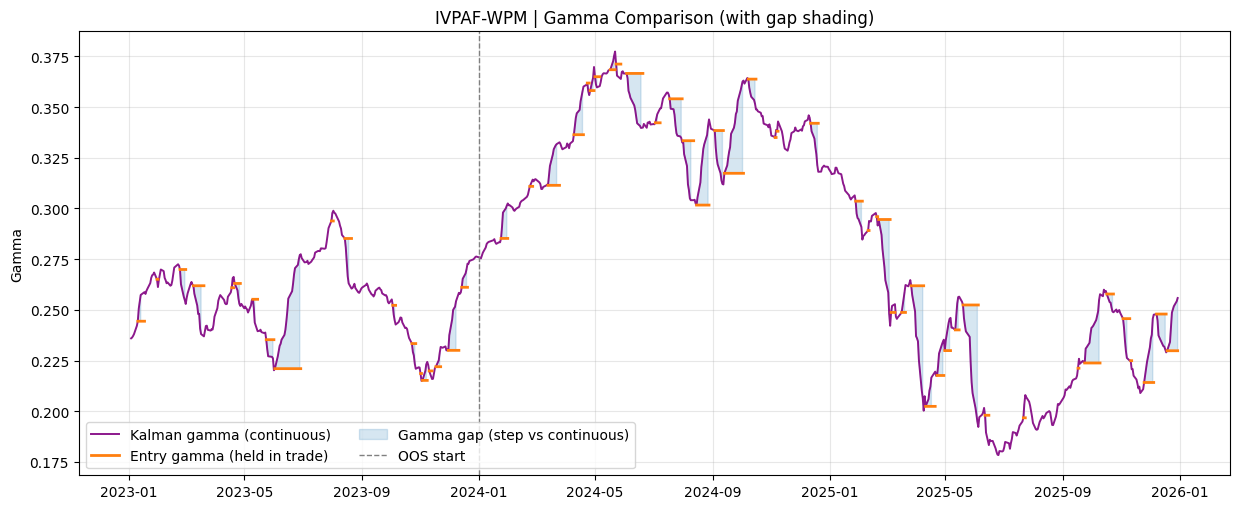

In [17]:
# pull threshold used for that pair from selected_pairs
row = selected_pairs.iloc[0]

threshold = float(row["is_best_threshold"])

target_tick1, target_tick2 = str(row["tick1"]), str(row["tick2"])

# rebuild pair series
df_pair = fetch_log_prices([target_tick1, target_tick2], BUFFER_START, OOS_END)
kf_pair = kalman_pair_frame(df_pair, target_tick1, target_tick2, IS_START, IS_END, alpha=ALPHA_KALMAN, z_window=Z_WINDOW)
if kf_pair is None:
    raise ValueError("Kalman prep failed for selected pair")

pos_pair, gamma_step_pair = build_positions_with_entry_gamma(
    kf_pair["z"], kf_pair["gamma"], threshold=threshold, exit_band=exit_band
)

gamma_cont_pair = kf_pair["gamma"]

# choose plot window (IS+OOS)
idx = gamma_cont_pair.loc[IS_START:OOS_END].index
g_cont = gamma_cont_pair.loc[IS_START:OOS_END]
g_step = gamma_step_pair.loc[IS_START:OOS_END]

# show step gamma only when in a position
g_step_active = g_step.where(pos_pair.loc[IS_START:OOS_END] != 0.0)

# show step gamma only when in a position
active = (pos_pair.loc[IS_START:OOS_END] != 0.0)
g_step_active = g_step.where(active)

# identify entry/exit points of each trade segment
starts = active & (~active.shift(1, fill_value=False))
ends = active & (~active.shift(-1, fill_value=False))
start_idx = active.index[starts]
end_idx = active.index[ends]

plt.figure(figsize=(12.5, 5.2))

# continuous Kalman gamma
plt.plot(idx, g_cont, lw=1.4, color="purple", alpha=0.9, label="Kalman gamma (continuous)")

# step gamma during active positions only
plt.step(idx, g_step_active, where="post", lw=2.0, color="tab:orange", label="Entry gamma (held in trade)")

# shade difference between the two curves only when a position is active
shade_mask = active & g_cont.notna() & g_step_active.notna()
plt.fill_between(
    idx,
    g_cont,
    g_step_active,
    where=shade_mask,
    color="tab:blue",
    alpha=0.18,
    interpolate=True,
    label="Gamma gap (step vs continuous)"
)

plt.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1, label="OOS start")
plt.title(f"{target_tick1}-{target_tick2} | Gamma Comparison (with gap shading)")
plt.ylabel("Gamma")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### Combined portfolio IS + OOS backtest

Pairs selected: 16

Portfolio Stats IS
total_return          0.270477
annualized_return     0.261153
annualized_vol        0.104993
sharpe                2.144459
max_drawdown         -0.064804
hit_ratio             0.530769
avg_active_pairs      5.780769
avg_gross_exposure    0.865397
dtype: float64

Top Contributors (PnL)
                          pnl  contribution_pct
GRAB-UPS|g4922   93994.472775          0.347513
APD-SQM|g3251    41241.202889          0.152476
F-MBGYY|g3361    38428.063990          0.142075
QSR-RSTRF|g7225  37971.099256          0.140386
CBOE-CME|g5232   26056.506605          0.096335
MCO-SPGI|g5614   21136.425275          0.078145
CL-LRLCY|g3256   13362.391411          0.049403
AKZOY-PPG|g3255  11956.222703          0.044204
KR-LBLCF|g4451   11159.420845          0.041258
BRO-MRSH|g5242   10978.095970          0.040588
DGX-LH|g6215      5514.953197          0.020390
BBY-JD|g4492      3550.081529          0.013125
FWONK-TKO|g7112    495.496012          0.001832
DT

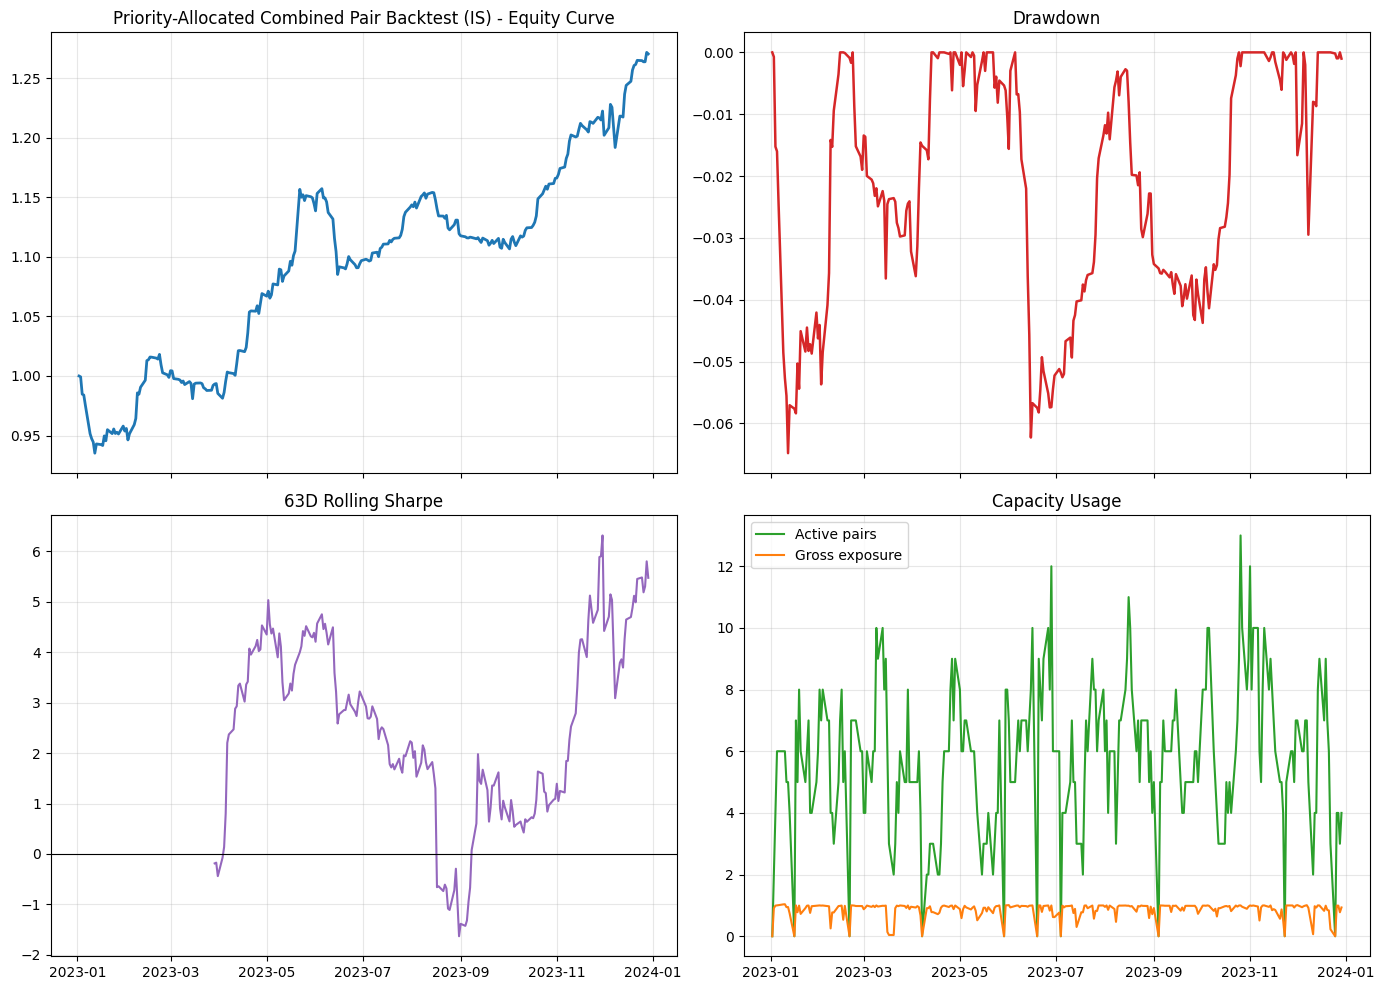


Portfolio Stats OOS
total_return          0.397293
annualized_return     0.174910
annualized_vol        0.138331
sharpe                1.004188
max_drawdown         -0.075762
hit_ratio             0.485660
avg_active_pairs      6.353728
avg_gross_exposure    0.869884
dtype: float64

Top Contributors (PnL)
                           pnl  contribution_pct
GRAB-UPS|g4922   112804.909831          0.283934
QSR-RSTRF|g7225  103045.986644          0.259370
BBY-JD|g4492      84119.909266          0.211732
DGX-LH|g6215      66945.278807          0.168503
KR-LBLCF|g4451    48069.761241          0.120993
IVPAF-WPM|g2122   43626.496839          0.109809
AKZOY-PPG|g3255   28120.057094          0.070779
FND-HD|g4441      16294.922936          0.041015
DTRUY-ITW|g3339    9949.318853          0.025043
CBOE-CME|g5232     7738.493435          0.019478
CL-LRLCY|g3256     5886.296107          0.014816
APD-SQM|g3251     -3243.540881         -0.008164
BRO-MRSH|g5242    -5301.696620         -0.013345
MCO-SP

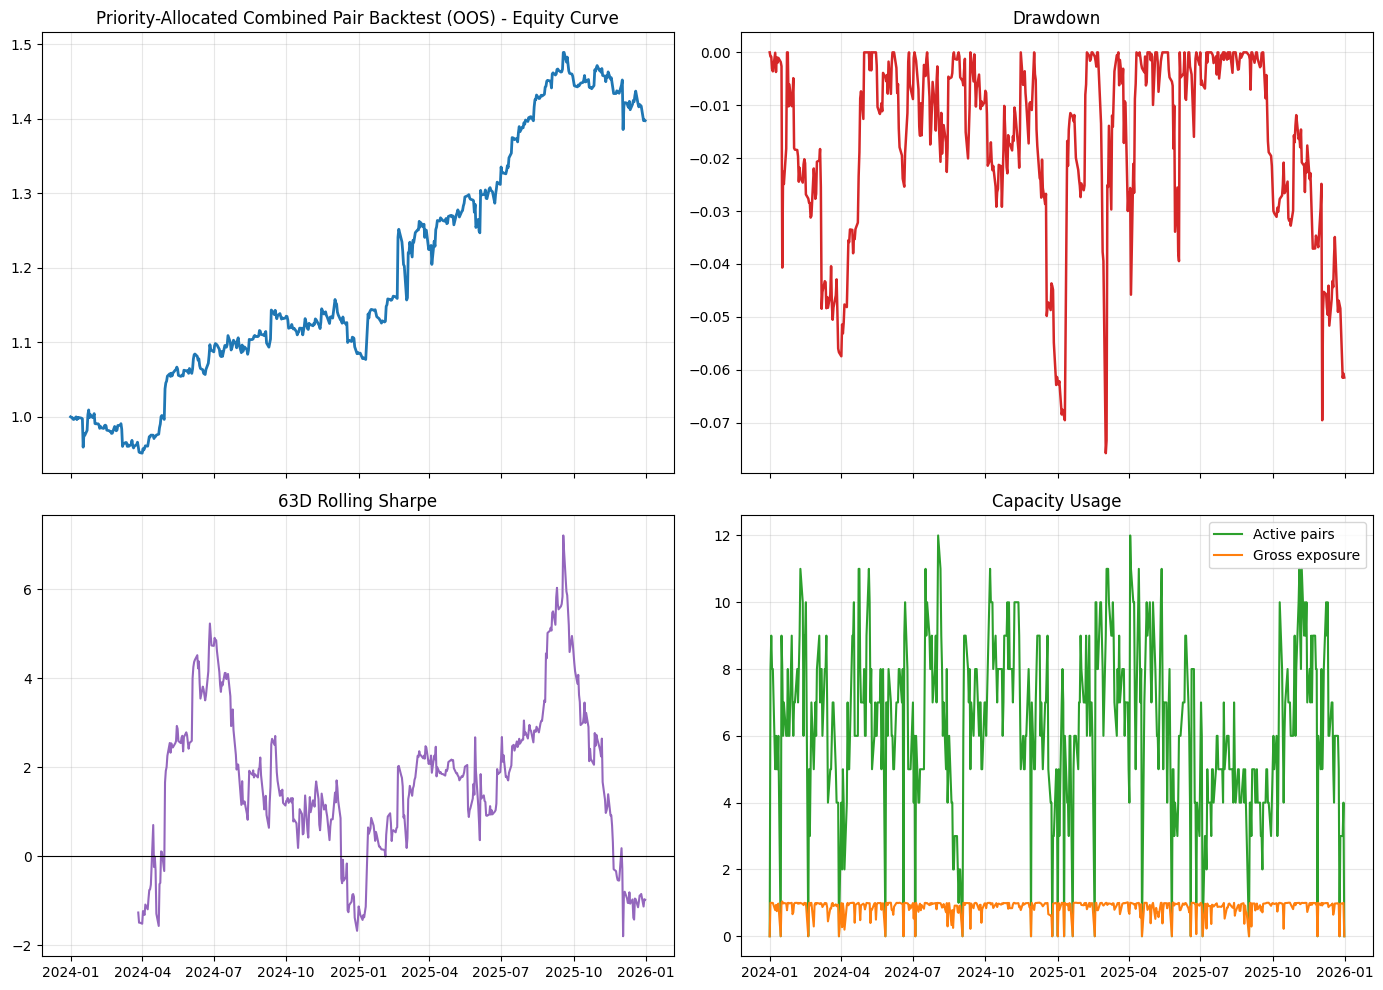

In [18]:

# ============================
# Run
# ============================

pair_panels_is, skipped_is = prepare_pair_panels(selected_pairs, IS_START, IS_END)
pair_panels_oos, skipped_oos = prepare_pair_panels(selected_pairs, OOS_START, OOS_END)


print(f"Pairs selected: {len(selected_pairs)}")
if skipped_is or skipped_oos:
    print("Skipped pairs:")
    for p, reason in skipped_is[:10]:
        print(f"  {p}: {reason}")
    if len(skipped_is) > 10:
        print(f"  ... and {len(skipped_is) - 10} more")
    for p, reason in skipped_oos[:10]:
        print(f"  {p}: {reason}")
    if len(skipped_oos) > 10:
        print(f"  ... and {len(skipped_oos) - 10} more")

res_is = run_combined_backtest(
    pair_panels_is,
    alloc_frac=ALLOC_FRAC,
    max_gross=MAX_GROSS,
    initial_capital=INITIAL_CAPITAL,
    tc_bps=TC_BPS
)

res_oos = run_combined_backtest(
    pair_panels_oos,
    alloc_frac=ALLOC_FRAC,
    max_gross=MAX_GROSS,
    initial_capital=INITIAL_CAPITAL,
    tc_bps=TC_BPS
)

if res_is is None:
    print("No usable pairs for combined backtest.")
else:
    portfolio_is, contrib_is, pair_state_is = res_is
    portfolio_oos, contrib_oos, pair_state_oos = res_oos
    stats_is = portfolio_stats(portfolio_is, rf_annual=RF_ANNUAL)
    stats_oos = portfolio_stats(portfolio_oos, rf_annual=RF_ANNUAL)

    print("\nPortfolio Stats IS")
    print(stats_is)
    print("\nTop Contributors (PnL)")
    print(contrib_is.head(15))
    plot_portfolio(portfolio_is, title="Priority-Allocated Combined Pair Backtest (IS)")

    print("\nPortfolio Stats OOS")
    print(stats_oos)
    print("\nTop Contributors (PnL)")
    print(contrib_oos.head(15))
    plot_portfolio(portfolio_oos, title="Priority-Allocated Combined Pair Backtest (OOS)")

In [19]:
def calculate_risk_metrics(returns, confidence_levels=(0.95, 0.99), target_return=0):
    """
    Calculate volatility, downside risk, VaR, and CVaR.

    Parameters
    ----------
    returns : array-like
        Portfolio return series in decimal form.
    confidence_levels : tuple
        Confidence levels for VaR and CVaR.
    target_return : float
        Minimum acceptable return used for downside risk. Default is 0.

    Returns
    -------
    dict
        Dictionary of risk metrics.
    """
    returns = np.asarray(returns, dtype=float).flatten()
    returns = returns[~np.isnan(returns)]

    mean_ret = np.mean(returns)
    std_dev = np.std(returns, ddof=1)   # sample volatility

    # downside risk (downside deviation)
    downside_diff = np.minimum(returns - target_return, 0)
    downside_risk = np.sqrt(np.mean(downside_diff**2))

    results = {
        "Volatility": std_dev,
        "Downside Risk": downside_risk
    }

    for cl in confidence_levels:
        alpha = 1 - cl
        label = f"{int(cl*100)}%"

        # Historical VaR and CVaR
        var_hist = np.percentile(returns, alpha * 100)
        cvar_hist = np.mean(returns[returns <= var_hist]) if np.any(returns <= var_hist) else np.nan

        # Parametric normal VaR and CVaR
        z = stats.norm.ppf(alpha)
        var_norm = mean_ret + std_dev * z
        cvar_norm = mean_ret - std_dev * stats.norm.pdf(z) / alpha

        results[f"Historical VaR {label}"] = var_hist
        results[f"Historical CVaR {label}"] = cvar_hist
        results[f"Normal VaR {label}"] = var_norm
        results[f"Normal CVaR {label}"] = cvar_norm

    return results

#### daily alpha and risk metrics

In [33]:
oos_ret = portfolio_oos["ret"].loc[OOS_START:OOS_END].fillna(0.0)
common_idx = oos_ret.index.intersection(daily_carhart.index)

rf_t = daily_carhart.loc[common_idx, "RF"]
rf_weight_t = portfolio_oos.loc[common_idx, "rf_exposure_weight"].fillna(0.0)

y = oos_ret.loc[common_idx] - rf_weight_t * rf_t
X = sm.add_constant(daily_carhart.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annualized alpha", (1+reg.params.iloc[0])**252-1)
alpha = reg.params.iloc[0]
residuals = reg.resid
tracking_error = residuals.std()

avg_daily_ret = oos_ret[common_idx].mean()
annualized_ret = (1 + avg_daily_ret) ** 252 - 1
print(f"Annualized Average Return: {annualized_ret:.4%}")

cum_return = (1 + oos_ret[common_idx]).prod() - 1
print(f"Cumulative Return: {cum_return:.4%}")

excess_ret = oos_ret.loc[common_idx] - rf_weight_t * rf_t
sharpe_ratio = (excess_ret.mean() / excess_ret.std()) * np.sqrt(252) if excess_ret.std() > 0 else np.nan
print(f"Sharpe Ratio (excess return): {sharpe_ratio:.4f}")

# Information Ratio
if tracking_error > 0:
    info_ratio = alpha / tracking_error
else:
    info_ratio = np.nan

# Market return series (daily total and excess)
market_excess_ret = daily_carhart.loc[common_idx, "Mkt-RF"]   # market excess return
market_total_ret = market_excess_ret + daily_carhart.loc[common_idx, "RF"]

# Market Sharpe (excess over RF)
market_sharpe = (
    np.sqrt(252) * market_excess_ret.mean() / market_excess_ret.std()
    if market_excess_ret.std() > 0 else np.nan
)
print(f"Market Sharpe Ratio (excess return): {market_sharpe:.4f}")

# Correlation: portfolio total return vs market total return
corr_port_market = oos_ret.loc[common_idx].corr(market_total_ret)
print(f"Correlation (Portfolio vs Market): {corr_port_market:.6f}")

alpha_SR_derived = (sharpe_ratio - corr_port_market * market_sharpe) * excess_ret.std() * np.sqrt(252)
print(f"Derived alpha from Sharpe and correlation: {alpha_SR_derived:.6f}")

print(f"Information Ratio: {info_ratio:.6f}")
print(reg.summary())

annualized alpha 0.18712556528938085
Annualized Average Return: 20.3452%
Cumulative Return: 41.8137%
Sharpe Ratio (excess return): 1.3064
Market Sharpe Ratio (excess return): 0.9701
Correlation (Portfolio vs Market): 0.119979
Derived alpha from Sharpe and correlation: 0.168019
Information Ratio: 0.077310
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.456
Date:                Wed, 22 Apr 2026   Prob (F-statistic):             0.0449
Time:                        17:17:08   Log-Likelihood:                 1663.7
No. Observations:                 502   AIC:                            -3317.
Df Residuals:                     497   BIC:                            -3296.
Df Model:                           4                         

In [21]:
metrics = calculate_risk_metrics(oos_ret.loc[common_idx], confidence_levels=(0.95, 0.99), target_return=0)

# ---------------------------------------------------
# Pretty output table
# ---------------------------------------------------
risk_table = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Value": list(metrics.values())
})

risk_table["Value"] = risk_table["Value"].apply(lambda x: f"{x:.4%}")

print("Daily Risk Metrics Summary")
print(risk_table.to_string(index=False))

Daily Risk Metrics Summary
             Metric    Value
         Volatility  0.8890%
      Downside Risk  0.5152%
 Historical VaR 95% -0.9436%
Historical CVaR 95% -1.7331%
     Normal VaR 95% -1.3888%
    Normal CVaR 95% -1.7602%
 Historical VaR 99% -2.3542%
Historical CVaR 99% -3.2196%
     Normal VaR 99% -1.9946%
    Normal CVaR 99% -2.2959%


#### Monthly alpha and risk metrics

In [36]:
monthly_carhart = carhart_df.loc[carhart_df.index.isin(oos_ret.index.strftime('%Y-%m'))]
oos_ret = portfolio_oos["ret"].loc[OOS_START:OOS_END].fillna(0.0)
day_common_idx = oos_ret.index.intersection(daily_carhart.index)

rf_t = daily_carhart.loc[day_common_idx, "RF"]
rf_weight_t = portfolio_oos.loc[day_common_idx, "rf_exposure_weight"].fillna(0.0)
monthly_returns = (oos_ret.loc[day_common_idx] - rf_weight_t * rf_t).resample('ME').sum()
monthly_returns.index = monthly_returns.index.strftime('%Y-%m')
mth_common_idx = monthly_returns.index.intersection(monthly_carhart.index)

y = monthly_returns.loc[mth_common_idx]
X = sm.add_constant(monthly_carhart.loc[mth_common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annualized alpha", (1+reg.params.iloc[0])**12-1)
alpha = reg.params.iloc[0]
residuals = reg.resid
tracking_error = residuals.std()

avg_monthly_ret = monthly_returns[mth_common_idx].mean()
annualized_ret = (1 + avg_monthly_ret) ** 12 - 1
print(f"Annualized Average Return: {annualized_ret:.4%}")
cum_return = (1 + monthly_returns[mth_common_idx]).prod() - 1
print(f"Cumulative Return: {cum_return:.4%}")

sharpe_ratio = (monthly_returns[mth_common_idx].mean() / monthly_returns[mth_common_idx].std()) * np.sqrt(12) if monthly_returns[mth_common_idx].std() > 0 else np.nan
print(f"Sharpe Ratio (excess return): {sharpe_ratio:.4f}")

# Information Ratio
if tracking_error > 0:
    info_ratio = alpha / tracking_error
else:
    info_ratio = np.nan

# Market return series (daily total and excess)
market_excess_ret = monthly_carhart.loc[mth_common_idx, "Mkt-RF"]   # market excess return
market_total_ret = market_excess_ret + monthly_carhart.loc[mth_common_idx, "RF"]

# Market Sharpe (excess over RF)
market_sharpe = (
    np.sqrt(12) * market_excess_ret.mean() / market_excess_ret.std()
    if market_excess_ret.std() > 0 else np.nan
)
print(f"Market Sharpe Ratio (excess return): {market_sharpe:.4f}")

# Correlation: portfolio total return vs market total return
oos_ret_monthly = oos_ret.loc[day_common_idx].resample('ME').sum()
oos_ret_monthly.index = oos_ret_monthly.index.strftime('%Y-%m') 
corr_port_market = oos_ret_monthly.corr(market_total_ret)
print(f"Correlation (Portfolio vs Market): {corr_port_market:.6f}")

alpha_SR_derived = (sharpe_ratio - corr_port_market * market_sharpe) * monthly_returns[mth_common_idx].std() * np.sqrt(12)
print(f"Derived alpha from Sharpe and correlation: {alpha_SR_derived:.6f}")

print(f"Information Ratio: {info_ratio:.6f}")
print(reg.summary())

annualized alpha 0.24349679686876335
Annualized Average Return: 20.0009%
Cumulative Return: 42.3240%
Sharpe Ratio (excess return): 1.6327
Market Sharpe Ratio (excess return): 1.3669
Correlation (Portfolio vs Market): -0.177052
Derived alpha from Sharpe and correlation: 0.210954
Information Ratio: 0.584503
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                 -0.128
Method:                 Least Squares   F-statistic:                    0.3484
Date:                Wed, 22 Apr 2026   Prob (F-statistic):              0.842
Time:                        17:18:25   Log-Likelihood:                 49.554
No. Observations:                  24   AIC:                            -89.11
Df Residuals:                      19   BIC:                            -83.22
Df Model:                           4                        

In [23]:
metrics = calculate_risk_metrics(monthly_returns.loc[common_idx], confidence_levels=(0.95, 0.99), target_return=0)

# ---------------------------------------------------
# Pretty output table
# ---------------------------------------------------
risk_table = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Value": list(metrics.values())
})

risk_table["Value"] = risk_table["Value"].apply(lambda x: f"{x:.4%}")

print("Monthly Risk Metrics Summary")
print(risk_table.to_string(index=False))

Monthly Risk Metrics Summary
             Metric    Value
         Volatility  3.2483%
      Downside Risk  1.3539%
 Historical VaR 95% -2.8798%
Historical CVaR 95% -3.5590%
     Normal VaR 95% -3.8120%
    Normal CVaR 95% -5.1694%
 Historical VaR 99% -3.8885%
Historical CVaR 99% -4.1692%
     Normal VaR 99% -6.0258%
    Normal CVaR 99% -7.1265%


In [24]:
# ---------- Helpers ----------
def add_text_pages_to_pdf_local(pdf, text, title="", max_chars=120, lines_per_page=48, fontsize=9):
    wrapped = []
    for line in str(text).splitlines():
        wrapped.extend(textwrap.wrap(line, width=max_chars) or [""])
    if not wrapped:
        wrapped = [""]

    total_pages = int(np.ceil(len(wrapped) / lines_per_page))
    for p in range(total_pages):
        chunk = wrapped[p * lines_per_page:(p + 1) * lines_per_page]
        fig = plt.figure(figsize=(11.69, 8.27))  # A4 landscape
        fig.patch.set_facecolor("white")
        if title:
            fig.text(0.02, 0.98, f"{title} (page {p+1}/{total_pages})",
                     va="top", ha="left", fontsize=11, fontweight="bold")
        fig.text(0.02, 0.94, "\n".join(chunk), va="top", ha="left",
                 family="monospace", fontsize=fontsize)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

def add_df_pages(pdf, df, title, rows_per_page=24, fontsize=8):
    if df is None or len(df) == 0:
        add_text_pages_to_pdf_local(pdf, "No rows.", title=title)
        return

    df_show = df.copy()
    n = len(df_show)
    pages = int(np.ceil(n / rows_per_page))

    for i in range(pages):
        chunk = df_show.iloc[i*rows_per_page:(i+1)*rows_per_page]
        fig, ax = plt.subplots(figsize=(11.69, 8.27))
        ax.axis("off")
        ax.set_title(f"{title} (page {i+1}/{pages})", loc="left", fontsize=12, fontweight="bold")
        tbl = ax.table(
            cellText=chunk.values,
            colLabels=chunk.columns,
            loc="center"
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(fontsize)
        tbl.scale(1, 1.2)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

def risk_dict_to_df(risk_dict, period, frequency):
    out = pd.DataFrame({
    "Metric": list(risk_dict.keys()),
    "Value": list(risk_dict.values())
    })
    out["Period"] = period
    out["Frequency"] = frequency
    out["Value"] = out["Value"].apply(lambda x: f"{x:.4%}" if pd.notna(x) else "NaN")
    return out[["Period", "Frequency", "Metric", "Value"]]

def make_portfolio_figure(portfolio_df, title="Combined Pair Portfolio"):
    eq = portfolio_df["nav"] / portfolio_df["nav"].iloc[0]
    dd = eq / eq.cummax() - 1.0
    roll_sharpe = (
        (portfolio_df["ret"].rolling(63).mean() * 252) /
        (portfolio_df["ret"].rolling(63).std() * np.sqrt(252))
    )

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    axs[0, 0].plot(eq.index, eq.values, lw=2, color="tab:blue")
    axs[0, 0].set_title(f"{title} - Equity Curve")
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(dd.index, dd.values, lw=1.8, color="tab:red")
    axs[0, 1].set_title("Drawdown")
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].plot(roll_sharpe.index, roll_sharpe.values, lw=1.5, color="tab:purple")
    axs[1, 0].axhline(0, color="black", lw=0.8)
    axs[1, 0].set_title("63D Rolling Sharpe")
    axs[1, 0].grid(True, alpha=0.3)

    axs[1, 1].plot(portfolio_df.index, portfolio_df["n_active"], lw=1.5, label="Active pairs", color="tab:green")
    axs[1, 1].plot(portfolio_df.index, portfolio_df["gross_exposure"], lw=1.5, label="Gross exposure", color="tab:orange")
    axs[1, 1].set_title("Capacity Usage")
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# ---------- Validate required objects ----------
required = ["selected_pairs", "portfolio_is", "contrib_is", "stats_is", "portfolio_oos", "contrib_oos", "stats_oos", "daily_carhart", "carhart_df",
            "OOS_START", "OOS_END", "METHOD", "IS_START", "IS_END"]
missing = [x for x in required if x not in globals()]
if missing:
    raise ValueError(f"Missing required objects: {missing}. Run previous backtest cells first.")

# ---------- Recompute alpha analyses (clean, consistent) ----------
oos_ret = portfolio_oos["ret"].loc[OOS_START:OOS_END].fillna(0.0)

# Daily alpha regression (use portfolio-specific RF weight, not full RF)
common_idx_d = oos_ret.index.intersection(daily_carhart.index)
rf_d = daily_carhart.loc[common_idx_d, "RF"]
rf_w_d = portfolio_oos.loc[common_idx_d, "rf_exposure_weight"].fillna(0.0)

excess_daily = oos_ret.loc[common_idx_d] - rf_w_d * rf_d

y_d = excess_daily
X_d = sm.add_constant(daily_carhart.loc[common_idx_d, ["Mkt-RF", "SMB", "HML", "Mom"]])
reg_daily = sm.OLS(y_d, X_d).fit()
alpha_daily_ann = (1 + reg_daily.params.iloc[0]) ** 252 - 1

# Monthly alpha regression (aggregate weighted daily excess to monthly)
monthly_excess = excess_daily.resample("ME").sum()
monthly_excess.index = monthly_excess.index.strftime("%Y-%m")

monthly_carhart = carhart_df.loc[carhart_df.index.isin(monthly_excess.index)]
common_idx_m = monthly_excess.index.intersection(monthly_carhart.index)

y_m = monthly_excess.loc[common_idx_m]
X_m = sm.add_constant(monthly_carhart.loc[common_idx_m, ["Mkt-RF", "SMB", "HML", "Mom"]])
reg_monthly = sm.OLS(y_m, X_m).fit()
alpha_monthly_ann = (1 + reg_monthly.params.iloc[0]) ** 12 - 1

# ---------- Risk metrics ----------
common_idx_d_oos = oos_ret.index.intersection(daily_carhart.index)

risk_oos_daily = calculate_risk_metrics(oos_ret.loc[common_idx_d_oos], confidence_levels=(0.95, 0.99), target_return=0)

monthly_returns_oos = oos_ret.resample("ME").sum()
monthly_returns_oos.index = monthly_returns_oos.index.strftime("%Y-%m")
monthly_carhart_oos = carhart_df.loc[carhart_df.index.isin(monthly_returns_oos.index)]
common_idx_m_oos = monthly_returns_oos.index.intersection(monthly_carhart_oos.index)
risk_oos_monthly = calculate_risk_metrics(monthly_returns_oos.loc[common_idx_m_oos], confidence_levels=(0.95, 0.99), target_return=0)

risk_table_oos = pd.DataFrame({
"Daily": pd.Series(risk_oos_daily),
"Monthly": pd.Series(risk_oos_monthly),
})
risk_table_oos.index.name = "Metric"
risk_table_oos = risk_table_oos.apply(
lambda col: col.map(lambda x: f"{x:.4%}" if pd.notna(x) else "NaN")
).reset_index()

# ---------- Build report ----------
output_dir = report_dir / "combined"
output_dir.mkdir(exist_ok=True)
report_path = output_dir / f"combined_portfolio_report_{METHOD}_{IS_START[:4]}_{IS_END[:4]}_{OOS_START[:4]}_{OOS_END[:4]}.pdf"

with PdfPages(report_path) as pdf:
    # Cover / summary
    run_summary = (
        "Combined Portfolio Report\n"
        f"Method: {METHOD}\n"
        f"IS: {IS_START} to {IS_END}\n"
        f"OOS: {OOS_START} to {OOS_END}\n"
        f"Selected pairs count: {len(selected_pairs)}\n"
        f"OOS observations (daily): {len(common_idx_d)}\n"
        f"OOS observations (monthly): {len(common_idx_m)}\n"
        f"\nConfig:\n"
        f"INITIAL_CAPITAL={globals().get('INITIAL_CAPITAL', 'NA')}\n"
        f"ALLOC_FRAC={globals().get('ALLOC_FRAC', 'NA')}\n"
        f"MAX_GROSS={globals().get('MAX_GROSS', 'NA')}\n"
        f"Z_WINDOW={globals().get('Z_WINDOW', 'NA')}\n"
        f"Priority rule: Furthest abs distance to threshold (z - threshold)"
    )
    add_text_pages_to_pdf_local(pdf, run_summary, title="Run Summary")

    # Selected pairs
    sel_cols = [c for c in ["group", "tick1", "tick2", "is_adf_pvalue", "is_best_threshold", "is_sharpe", "oos_sharpe"] if c in selected_pairs.columns]
    add_df_pages(pdf, selected_pairs[sel_cols].reset_index(drop=True).round(4), title="Selected Pairs", rows_per_page=30)

    # Portfolio stats (IS VS OOS)
    stats_compare = pd.DataFrame({
    "metric": stats_is.index,
    "is_value": stats_is.values,
    "oos_value": stats_oos.reindex(stats_is.index).values
    })
    add_df_pages(pdf, stats_compare.round(4), title="IS vs OOS Portfolio Stats", rows_per_page=30)

    # Top contributors
    contrib_compare = pd.DataFrame({
    "pair_id": contrib_is.index,
    "is_pnl": contrib_is["pnl"].values,
    "is_contribution_pct": contrib_is["contribution_pct"].values,
    "oos_pnl": contrib_oos.reindex(contrib_is.index)["pnl"].values,
    "oos_contribution_pct": contrib_oos.reindex(contrib_is.index)["contribution_pct"].values
    })
    add_df_pages(pdf, contrib_compare.round(4), title="IS vs OOS PnL Contributors", rows_per_page=30)

    # IS + OOS combined cumulative return plot
    fig_isoos, ax = plt.subplots(figsize=(12, 5))
    is_curve = portfolio_is["nav"] / portfolio_is["nav"].iloc[0] - 1.0
    oos_curve = portfolio_oos["nav"] / portfolio_oos["nav"].iloc[0] - 1.0
    ax.plot(is_curve.index, is_curve.values, lw=2, color="tab:orange", label="IS combined return")
    ax.plot(oos_curve.index, oos_curve.values, lw=2, color="tab:green", label="OOS combined return (reset)")
    ax.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
    ax.set_title("Combined Portfolio Return: IS and OOS (OOS reset to 0)")
    ax.set_ylabel("Cumulative Return")
    ax.grid(True, alpha=0.3)
    ax.legend()
    pdf.savefig(fig_isoos, bbox_inches="tight")
    plt.close(fig_isoos)

    # Portfolio plots
    fig_port_is = make_portfolio_figure(portfolio_is, title="Priority-Allocated Combined Pair Portfolio")
    pdf.savefig(fig_port_is, bbox_inches="tight")
    plt.close(fig_port_is)

    fig_port_oos = make_portfolio_figure(portfolio_oos, title="Priority-Allocated Combined Pair Portfolio")
    pdf.savefig(fig_port_oos, bbox_inches="tight")
    plt.close(fig_port_oos)

    # Histogram of daily OOS returns
    fig_hist, ax = plt.subplots(figsize=(11, 6))
    ax.hist(oos_ret.values, bins=60, color="steelblue", alpha=0.85)
    ax.set_title("OOS Daily Return Distribution")
    ax.grid(True, alpha=0.25)
    pdf.savefig(fig_hist, bbox_inches="tight")
    plt.close(fig_hist)

    # Risk summary tables
    add_df_pages(pdf, risk_table_oos, title="OOS Risk Metrics (Daily vs Monthly)", rows_per_page=30)

    # Alpha summary tables
    alpha_summary = pd.DataFrame({
        "model": ["Daily Carhart", "Monthly Carhart"],
        "annualized_alpha": [alpha_daily_ann, alpha_monthly_ann],
        "r_squared": [reg_daily.rsquared, reg_monthly.rsquared],
        "n_obs": [int(reg_daily.nobs), int(reg_monthly.nobs)]
    })
    add_df_pages(pdf, alpha_summary, title="Alpha Summary", rows_per_page=20)

    # Full regression text outputs
    add_text_pages_to_pdf_local(pdf, reg_daily.summary().as_text(), title="Daily Regression Full Summary", max_chars=140, lines_per_page=52, fontsize=8)
    add_text_pages_to_pdf_local(pdf, reg_monthly.summary().as_text(), title="Monthly Regression Full Summary", max_chars=140, lines_per_page=52, fontsize=8)

print(f"Saved combined report to: {report_path}")

Saved combined report to: outputs\after_meeting\combined\combined_portfolio_report_Kalman_2023_2023_2024_2025.pdf
